# Explain clusters to business with Altair and Shapley values


In [1]:
print("Start")

Start


In [2]:
# Load python libraries for data handling and plotting
import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt

In [3]:
print(f'Altair version: {alt.__version__}')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

Altair version: 6.2.2
Pandas version: 3.0.5
Numpy version: 2.5.2


In [4]:
alt.data_transformers.enable("json")


DataTransformerRegistry.enable('json')

In [5]:
import os
import numpy as np
import pandas as pd

DATA_DIR = os.path.join("..", "data")
FEATURES = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
combined = os.path.join(DATA_DIR, "Beijing_MultiSite_AirQuality.csv")

def load_merged_air():
    if os.path.exists(combined):
        df = pd.read_csv(combined)
        if set(FEATURES).issubset(df.columns):
            return df
    scan_dirs = [DATA_DIR, os.path.join(DATA_DIR, "beijing"),
                 os.path.join(DATA_DIR, "PRSA_Data_20130301-20170228")]
    for subdir in scan_dirs:
        if not os.path.isdir(subdir):
            continue
        frames = []
        for fn in sorted(os.listdir(subdir)):
            if fn.lower().startswith("prsa_data_") and fn.lower().endswith(".csv"):
                tmp = pd.read_csv(os.path.join(subdir, fn))
                if not set(FEATURES).intersection(tmp.columns):
                    continue
                if "station" not in tmp.columns:
                    tmp["station"] = os.path.splitext(fn)[0]
                frames.append(tmp)
        if frames:
            df = pd.concat(frames, ignore_index=True)
            if set(FEATURES).issubset(df.columns):
                os.makedirs(DATA_DIR, exist_ok=True)
                df.to_csv(combined, index=False)
                return df
    raise RuntimeError("no Beijing air-quality data found in " + str(scan_dirs))

df = load_merged_air()
print("merged data shape:", df.shape, "| stations:", df["station"].nunique())

# This example notebook is an exploratory pipeline; work on a stratified
# subsample so the KMeans/SHAP cells run quickly (full data stays in df_full).
df_full = df.copy()
rng = np.random.RandomState(1301)
df = df.groupby("station", group_keys=False).apply(
    lambda g: g.sample(min(2000, len(g)), random_state=1301), include_groups=False
).reset_index(drop=True)
print("working subsample shape:", df.shape)


merged data shape: (420768, 18) | stations: 12


working subsample shape: (24000, 17)


In [6]:
df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,22502,2015,9,24,13,184.0,224.0,10.0,74.0,2300.0,58.0,23.1,1004.9,18.8,0.0,SE,1.3
1,27753,2016,4,30,8,194.0,194.0,9.0,66.0,1600.0,41.0,18.5,1000.4,11.1,0.0,NNE,2.6
2,10782,2014,5,24,5,67.0,131.0,6.0,NaN,600.0,23.0,19.4,1002.3,19.2,7.3,ENE,1.4
3,32194,2016,11,1,9,20.0,46.0,11.0,60.0,800.0,5.0,3.3,1032.6,-9.0,0.0,SE,0.9
4,32887,2016,11,30,6,141.0,173.0,10.0,96.0,4300.0,2.0,-0.7,1020.4,-2.1,0.0,SW,0.8


In [7]:
# df is already loaded by load_merged_air() above


In [8]:
# Show the first lines of the data set to get an idea what's in there.
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,22502,2015,9,24,13,184.0,224.0,10.0,74.0,2300.0,58.0,23.1,1004.9,18.8,0.0,SE,1.3
1,27753,2016,4,30,8,194.0,194.0,9.0,66.0,1600.0,41.0,18.5,1000.4,11.1,0.0,NNE,2.6
2,10782,2014,5,24,5,67.0,131.0,6.0,NaN,600.0,23.0,19.4,1002.3,19.2,7.3,ENE,1.4
3,32194,2016,11,1,9,20.0,46.0,11.0,60.0,800.0,5.0,3.3,1032.6,-9.0,0.0,SE,0.9
4,32887,2016,11,30,6,141.0,173.0,10.0,96.0,4300.0,2.0,-0.7,1020.4,-2.1,0.0,SW,0.8


In [9]:
# How many wines and features do we have ?
df.shape

(24000, 17)

In [10]:
# Drop irrelevant columns
df = df.drop(columns=['No', 'year','month','day','hour','station','wd'], errors='ignore')
# Drop rows with missing values
df = df.dropna()


In [11]:
# How many wines and features do we have ?
df.shape

(21802, 11)

In [12]:
df.columns

Index(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
       'RAIN', 'WSPM'],
      dtype='str')

In [13]:
df = df.rename(columns={
    'PM2.5': 'PM2P5',
})

In [14]:
df.columns

Index(['PM2P5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
       'RAIN', 'WSPM'],
      dtype='str')

In [15]:
alt.Chart(df).mark_point().encode(x='CO', y='NO2', color='O3')

alt.Chart(...)

In [16]:
# Define the standard X (feature matrix) and target series y (not used in here)
X =  df.drop(columns='PM2P5')
all_features = X.columns
y = df['PM2P5']

In [17]:
df.describe()

,PM2P5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000,21802.000000
mean,81.345028,105.291212,16.184834,50.773666,1237.397624,55.853959,13.543395,1010.650758,2.624713,0.072530,1.718984
std,82.207160,92.387899,22.290758,35.192826,1151.401664,56.104191,11.429807,10.412497,13.731586,0.882416,1.232251
min,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-19.900000,984.300000,-33.400000,0.000000,0.000000
25%,20.000000,36.000000,2.000000,23.000000,500.000000,11.000000,3.100000,1002.200000,-8.600000,0.000000,0.900000
50%,56.000000,82.000000,7.000000,44.000000,900.000000,44.000000,14.600000,1010.400000,3.700000,0.000000,1.400000
75%,113.000000,146.000000,20.000000,71.000000,1600.000000,80.000000,23.300000,1019.000000,15.000000,0.000000,2.200000
max,713.000000,948.000000,230.000000,280.000000,10000.000000,1071.000000,41.100000,1041.400000,28.200000,28.100000,10.000000


# Scaling

From the describe, we see that domains of the feature differ widely. Feature 'fixed acidity' has mean 6.854788, while feature 'volatile acidity' has mean 0.278241. This is a sign that are on a different scale. We scale the features first so that we can use them together.

In [18]:
# When features have different scale we have to scale them so that we can use them together
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
# scaler = RobustScaler()  # Take the robust scaler when data contains outliers that you want to remove

In [20]:
X_scaled = scaler.fit_transform(X)

# PCA

Perform principal component analysis to get an idea of the dimensionality of the wine dataset. Next reduce to two dimension so that we can make a 2D scatter plot were each dot is a wine from the set.

In [21]:
from sklearn.decomposition import PCA
pca = PCA().fit(X_scaled)

In [22]:
df_plot = pd.DataFrame({'Component Number': 1+np.arange(X.shape[1]),
                        'Cumulative explained variance': np.cumsum(pca.explained_variance_ratio_)})
alt.Chart(df_plot).mark_bar().encode(
    x=alt.X('Component Number:N', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('Cumulative explained variance', axis=alt.Axis(format='%', title='Percentage')),
    tooltip=[alt.Tooltip('Cumulative explained variance', format='.0%')]
).properties(
    title='Cumulative explained variance'
).properties(
    width=400
)

alt.Chart(...)

We see that almost all features are needed to explain all the variance. Only with 9 comoponent we can explain 97% of the variance. This means that we should use all features from the dataset and feature selection is not necessary in this case.

# PCA with 2 Dimensions

Perform dimension reduction to two dimentions with PCA to be able to draw all the wines in one graph (not for the clustering!)

In [23]:
twod_pca = PCA(n_components=2)
X_pca = twod_pca.fit_transform(X_scaled)

In [24]:
# Add first to PCA components to the dataset so we can plot it
df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

In [25]:
df['member'] = 1
df.groupby('PM2P5')['member'].transform('count').div(df.shape[0])

0        0.001926
1        0.001193
3        0.011559
4        0.002110
5        0.003899
           ...   
23995    0.006421
23996    0.016466
23997    0.006284
23998    0.007935
23999    0.005504
Name: member, Length: 21802, dtype: float64

In [26]:
selection = alt.selection_multi(fields=['PM2P5'], bind='legend')

df['PM2P5_weight'] = df['PM2P5'].map(df['PM2P5'].value_counts(normalize=True).to_dict())
# Draw 20% stratified sample
alt.Chart(df.sample(1000, weights='PM2P5_weight')).mark_circle(size=60).encode(
    x=alt.X('pca1', title='First component'),
    y=alt.Y('pca2', title='Second component'),
    color=alt.Color('PM2P5:N'),
    tooltip=['PM2P5'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2))
).properties(
    title='PCA analyse',
    width=600,
    height=400
).add_selection(
    selection
)

/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/1245738965.py:1: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  selection = alt.selection_multi(fields=['PM2P5'], bind='legend')
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/1245738965.py:15: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

In [27]:
df_twod_pca = pd.DataFrame(data=twod_pca.components_.T, columns=['pca1', 'pca2'], index=X.columns)

In [28]:
pca1 = alt.Chart(df_twod_pca.reset_index()).mark_bar().encode(
    y=alt.Y('index:O', title=None),
    x='pca1',
    color=alt.Color('pca1', scale=alt.Scale(scheme='viridis')),
    tooltip = [alt.Tooltip('index', title='Feature'), alt.Tooltip('pca1', format='.2f')]
)
pca2 = alt.Chart(df_twod_pca.reset_index()).mark_bar().encode(
    y=alt.Y('index:O', title=None),
    x='pca2',
    color=alt.Color('pca2', scale=alt.Scale(scheme='viridis')),
    tooltip = [alt.Tooltip('index', title='Feature'), alt.Tooltip('pca2', format='.2f')]
)

(pca1 & pca2).properties(
    title='Loadings of the first two principal components'
)

alt.VConcatChart(...)

# Kmeans clustering

Determine the number of cluster for Kmeans clustering by lopping from 2 to 11 cluster. Calculate for each result the within-cluster variation (inertia), the [silhoutte](https://en.wikipedia.org/wiki/Silhouette_(clustering)) and the [Davies-Bouldin index](n.wikipedia.org/wiki/Davies–Bouldin_index). Use the elbow method to determine the number of clusters. The elbow method seeks the value of k after which the clustering quality improves only marginally.

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [30]:
km_scores= []
km_silhouette = []
km_db_score = []
for i in range(2,X.shape[1]):
    km = KMeans(n_clusters=i, random_state=1301).fit(X_scaled)
    preds = km.predict(X_scaled)

    print(f'Score for number of cluster(s) {i}: {km.score(X_scaled):.3f}')
    km_scores.append(-km.score(X_scaled))

    silhouette = silhouette_score(X_scaled,preds)
    km_silhouette.append(silhouette)
    print(f'Silhouette score for number of cluster(s) {i}: {silhouette:.3f}')

    db = davies_bouldin_score(X_scaled,preds)
    km_db_score.append(db)
    print(f'Davies Bouldin score for number of cluster(s) {i}: {db:.3f}')

    print('-'*100)

Score for number of cluster(s) 2: -162588.886


Silhouette score for number of cluster(s) 2: 0.271
Davies Bouldin score for number of cluster(s) 2: 1.484
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 3: -127888.263


Silhouette score for number of cluster(s) 3: 0.284
Davies Bouldin score for number of cluster(s) 3: 1.234
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 4: -114717.491


Silhouette score for number of cluster(s) 4: 0.231
Davies Bouldin score for number of cluster(s) 4: 1.376
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 5: -97080.839


Silhouette score for number of cluster(s) 5: 0.235
Davies Bouldin score for number of cluster(s) 5: 1.150
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 6: -87192.967


Silhouette score for number of cluster(s) 6: 0.216
Davies Bouldin score for number of cluster(s) 6: 1.255
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 7: -80451.499


Silhouette score for number of cluster(s) 7: 0.213
Davies Bouldin score for number of cluster(s) 7: 1.269
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 8: -75773.529


Silhouette score for number of cluster(s) 8: 0.205
Davies Bouldin score for number of cluster(s) 8: 1.308
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 9: -72060.178


Silhouette score for number of cluster(s) 9: 0.212
Davies Bouldin score for number of cluster(s) 9: 1.279
----------------------------------------------------------------------------------------------------


In [31]:
df_plot = pd.DataFrame({'Number of clusters':[i for i in range(2,X.shape[1])],'kmean score': km_scores})
alt.Chart(df_plot).mark_line(point=True).encode(
    x=alt.X('Number of clusters:N', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('kmean score'),
    tooltip=[alt.Tooltip('kmean score', format='.2f')]
).properties(
    title='Kmean score ifo number of cluster'
).properties(
    title='The elbow method for determining number of clusters',
    width=400
)

alt.Chart(...)

In [32]:
df_plot = pd.DataFrame({'Number of clusters':[i for i in range(2,X.shape[1])],'silhouette score': km_silhouette})
alt.Chart(df_plot).mark_line(point=True).encode(
    x=alt.X('Number of clusters:N', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('silhouette score'),
    tooltip=[alt.Tooltip('silhouette score', format='.2f')]
).properties(
    title='Silhouette  score ifo number of cluster',
    width=400
)

alt.Chart(...)

In [33]:
df_plot = pd.DataFrame({'Number of clusters':[i for i in range(2, X.shape[1])],'davies bouldin score': km_db_score})
alt.Chart(df_plot).mark_line(point=True).encode(
    x=alt.X('Number of clusters:N', axis=alt.Axis(labelAngle=0)),
    y=alt.Y('davies bouldin score'),
    tooltip=[alt.Tooltip('davies bouldin score', format='.2f')]
).properties(
    title='Davies Bouldin score ifo number of cluster',
    width=400
)

alt.Chart(...)

For n_clusters = 2 The average silhouette_score is : 0.7017122859087432


For n_clusters = 3 The average silhouette_score is : 0.6236593015240539


For n_clusters = 4 The average silhouette_score is : 0.544750058315614


For n_clusters = 5 The average silhouette_score is : 0.5460060784093639


For n_clusters = 6 The average silhouette_score is : 0.4931997117469842


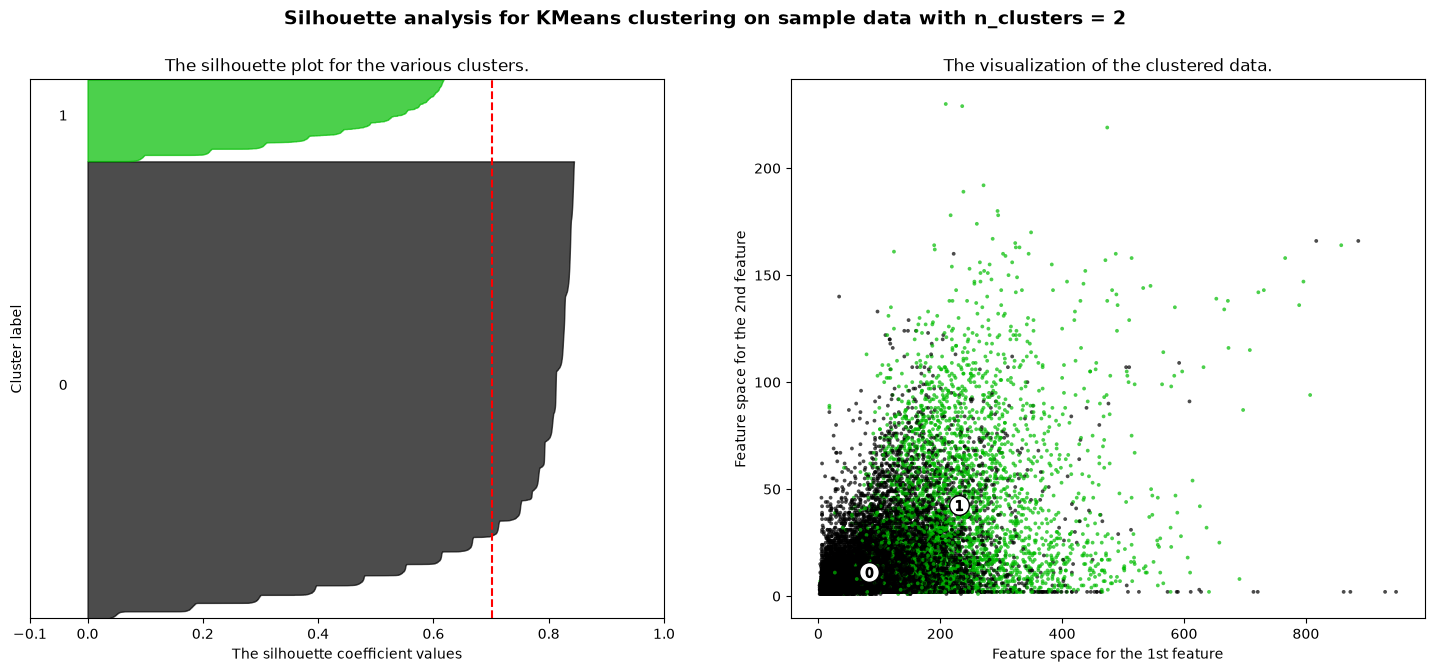

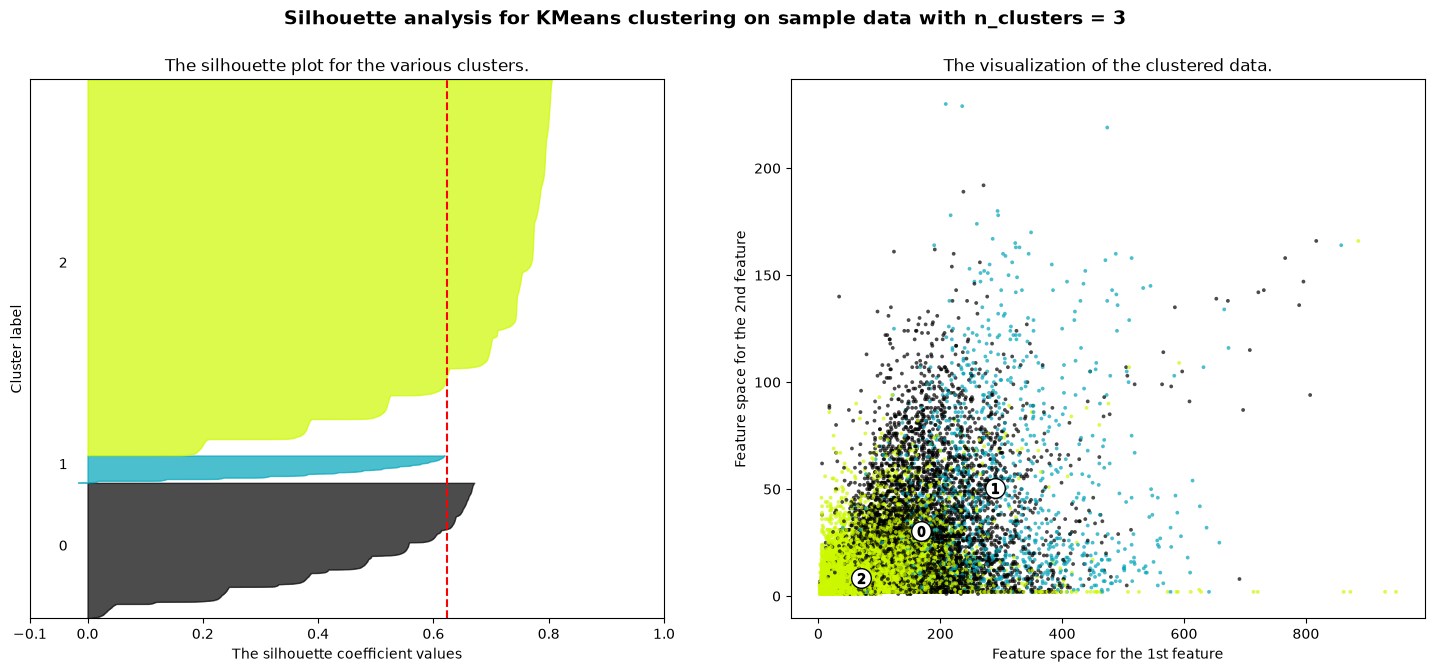

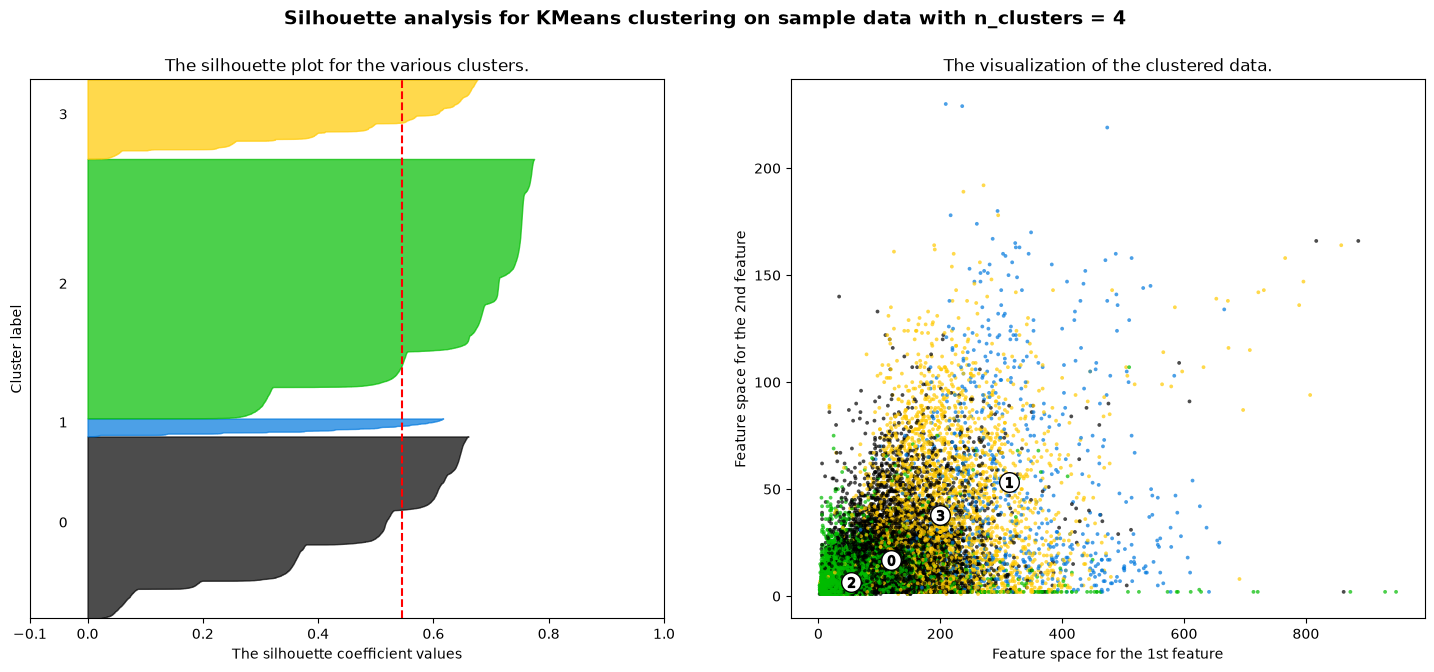

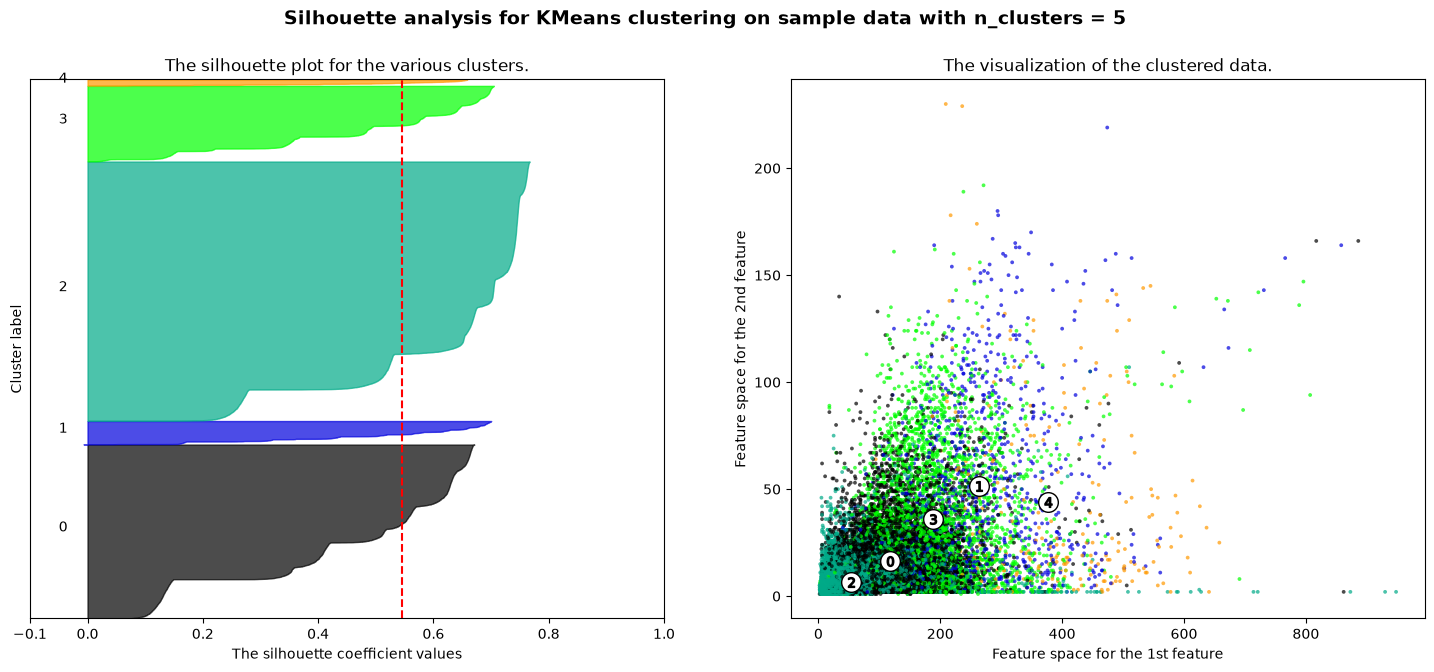

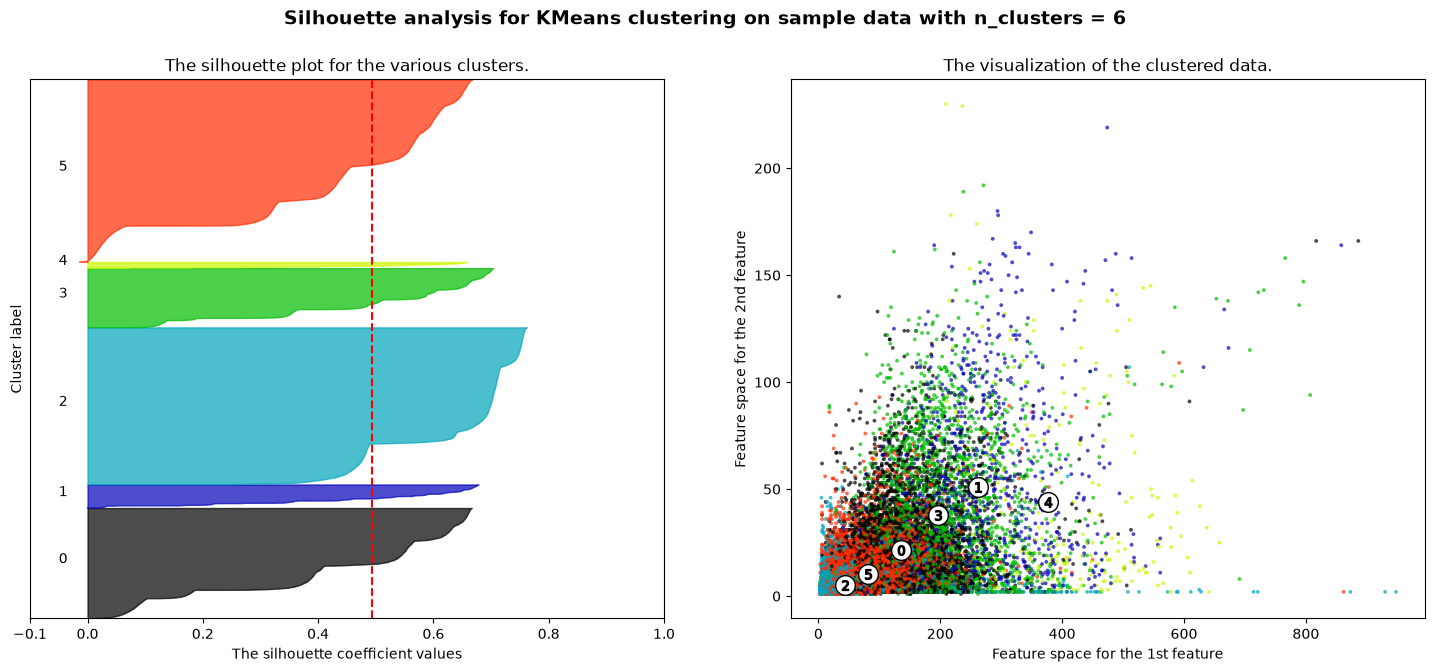

In [34]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

X = X.values
range_n_clusters = [2, 3, 4, 5, 6]
for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

plt.show()

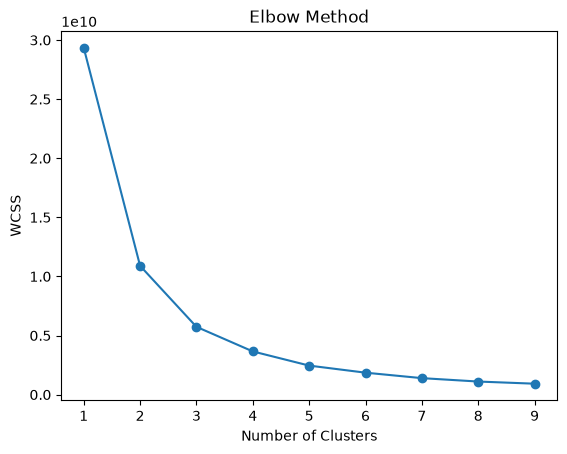

In [35]:
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)  # WCSS is the inertia attribute

# Plot WCSS
import matplotlib.pyplot as plt
plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [36]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df)

# Calculate Silhouette Score
silhouette_avg = silhouette_score(df, clusters)
print(f"Silhouette Score: {silhouette_avg}")


Silhouette Score: 0.6208319884008162


In [37]:
from sklearn.metrics import davies_bouldin_score

# Calculate Davies-Bouldin Score
db_score = davies_bouldin_score(df, clusters)
print(f"Davies-Bouldin Score: {db_score}")


Davies-Bouldin Score: 0.56255116002787


# Make three clusters

Since we have a high Davies Boldin and low Silhoutte score for k=3 we select to cluster into three clusters. Another option could be to use the [Gaussian Likelihood score](https://github.com/kerighan/gls). In this [notebook](https://www.kaggle.com/xvivancos/tutorial-clustering-wines-with-k-means) another analysis reported also 3 clusters.

In [38]:
km = KMeans(n_clusters=3, random_state=1301).fit(X_scaled)
preds = km.predict(X_scaled)
pd.Series(preds).value_counts() # How many wines are in each cluster ?

0    10420
2     6708
1     4674
Name: count, dtype: int64

In [39]:
df_km = pd.DataFrame(data={'pca1':X_pca[:,0], 'pca2':X_pca [:,1], 'cluster':preds})

In [40]:
# Add the scaled data with the input features

for i,c in enumerate(all_features):
    df_km[c] = X_scaled[:,i]

In [41]:
domain = [0, 1, 2]
range_ = ['red',  'darkblue', 'green']

selection = alt.selection_multi(fields=['cluster'], bind='legend')

pca = alt.Chart(df_km).mark_circle(size=20).encode(
    x='pca1',
    y='pca2',
    color=alt.Color('cluster:N', scale=alt.Scale(domain=domain, range=range_)),
    opacity=alt.condition(selection, alt.value(1), alt.value(0.1)),
    tooltip = list(all_features)
).add_selection(
    selection
)

pca

/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/1710701547.py:4: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use selection_point instead.
  selection = alt.selection_multi(fields=['cluster'], bind='legend')
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/1710701547.py:12: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

Now we will plot the all the wines on a two dimensional plane. On the right, you get boxplots for every feature. The cool thing is now that with the mouse you can select by drawing a brush over the points (click, hold button and drag the mouse) and get immediate updates boxplots of the features of the selected wines. A such you can interactively gain some insight in what the cluster might mean.

In [42]:
brush = alt.selection(type='interval')

domain = [0, 1, 2]
range_ = ['red', 'darkblue', 'green']

points = alt.Chart(df_km).mark_circle(size=60).encode(
    x='pca1',
    y='pca2',
    color = alt.condition(brush, 'cluster:N', alt.value('lightgray')),
    tooltip = list(all_features)
).add_selection(brush)

boxplots = alt.vconcat()
for measure in all_features:
    boxplot = alt.Chart(df_km).mark_boxplot().encode(
            x =alt.X(measure, axis=alt.Axis(titleX=470, titleY=0)),
    ).transform_filter(
            brush
    )
    boxplots &= boxplot

chart = alt.hconcat(points, boxplots)
# chart.save('cluster_pca_n_3.html'))
chart

/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/2855077864.py:1: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  brush = alt.selection(type='interval')
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_95482/2855077864.py:11: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(brush)


alt.HConcatChart(...)

AS you can't select al wine from one cluster with the rectangular brush, we make a plot for each cluster and boxplots of the features values of that cluster.

In [43]:
def plot_cluster(df, selected_columns, clusternr):
    points = alt.Chart(df).mark_circle(size=60).encode(
    x=alt.X('pca1', title='Principal component 1 (pca1)'),
    y=alt.Y('pca2', title='Principal component 2 (pca1)'),
    color = alt.condition(alt.FieldEqualPredicate(field='cluster', equal=clusternr), 'cluster:N', alt.value('lightgray')),
    tooltip = list(all_features)+['cluster'],
)

    boxplots = alt.vconcat()
    for measure in  [c for c in selected_columns]:
        boxplot = alt.Chart(df).mark_boxplot().encode(
                x =alt.X(measure, axis=alt.Axis(titleX=480, titleY=0)),
        ).transform_filter(
                alt.FieldEqualPredicate(field='cluster', equal=clusternr)
        )
        boxplots &= boxplot
    return points, boxplots

In [44]:
points, boxplots = plot_cluster(df_km, all_features, 0)
c0 = alt.hconcat(points, boxplots).properties(title='Cluster 0')
points, boxplots = plot_cluster(df_km, all_features, 1)
c1 = alt.hconcat(points, boxplots).properties(title='Cluster 1')
points, boxplots = plot_cluster(df_km, all_features, 2)
c2 = alt.hconcat(points, boxplots).properties(title='Cluster 2')

In [45]:
alt.vconcat(c0, c1, c2)

alt.VConcatChart(...)

I might still be difficult to explain the clusters. We will now build a multiclass classifier to predict the cluster from the features. Next we will use the Shapley values to explain the clusters.

# Light gbm classifier

In [46]:
import lightgbm as lgb

In [47]:
params = lgb.LGBMClassifier().get_params()
params

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [48]:
params['objective'] = 'multiclass' # the target to predict is the number of the cluster
params['is_unbalance'] = True
params['n_jobs'] = -1
params['random_state'] = 1301

In [49]:
mdl = lgb.LGBMClassifier(**params)

In [50]:
X =  df.drop(columns=['PM2P5', 'pca1', 'pca2', 'member'])

In [51]:
mdl.fit(X, preds)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 21802, number of used features: 11
[LightGBM] [Info] Start training from score -0.738275
[LightGBM] [Info] Start training from score -1.539986
[LightGBM] [Info] Start training from score -1.178701


,objective,'multiclass'
,random_state,1301
,n_jobs,-1
,is_unbalance,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,class_weight,None


In [52]:
y_pred = mdl.predict_proba(X)

In [53]:
import shap

/Users/mlouhichi/Desktop/GAS-BayesSHAP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
# Robust per-class SHAP extraction: multiclass list OR (n, f, c) array.
def class_shap(sv, n_test, n_classes, c):
    a = np.asarray(sv)
    if a.ndim == 3:
        if a.shape[0] == n_test and a.shape[2] == n_classes:
            return a[:, :, c]
        return a[c]
    return a

explainer = shap.TreeExplainer(mdl)
shap_values_raw = explainer.shap_values(X)
n_classes = len(mdl.classes_)
n_test = X.shape[0]
# replace per-class indexing with a robust helper (see cell 67)
shap_values = shap_values_raw


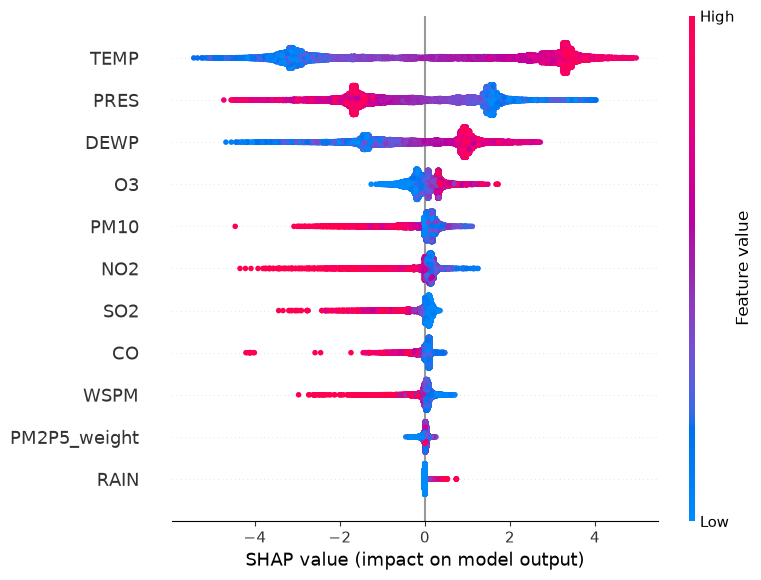

In [55]:
shap.summary_plot(class_shap(shap_values_raw, n_test, n_classes, 0), X, max_display=30)


From the Shapley values we see that the feature density has the highest impact on the model to predict the clusters. Let's have a look the Shapley values per cluster. The acidity features pH and fixed acidity has only impact on cluster 1 and 2 but almost none on cluster 0.

# Shapley values for the three clusters

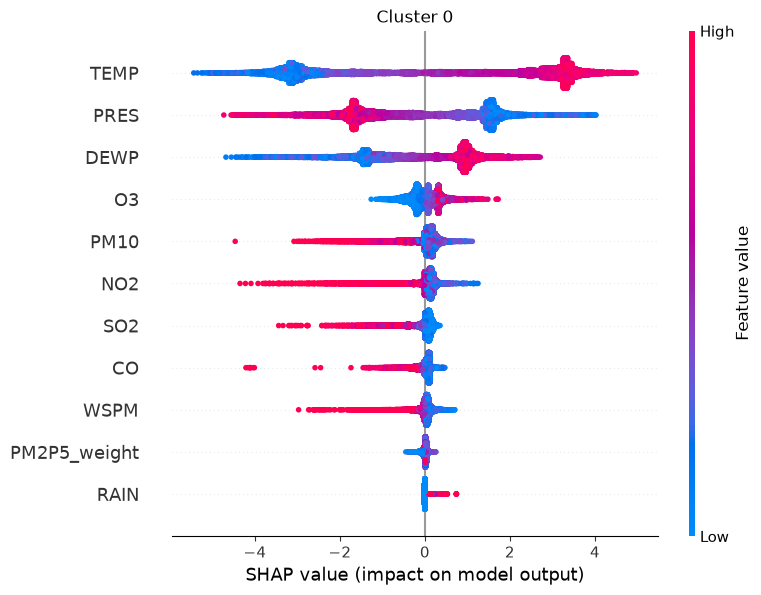

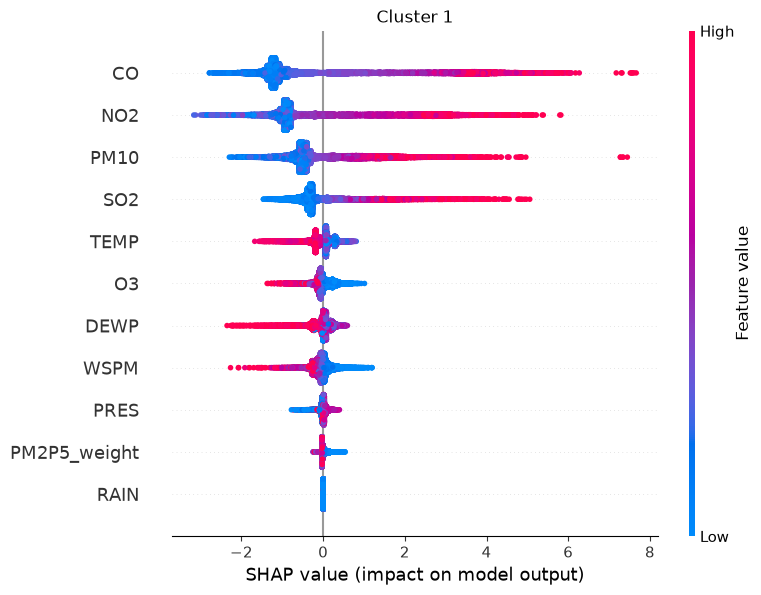

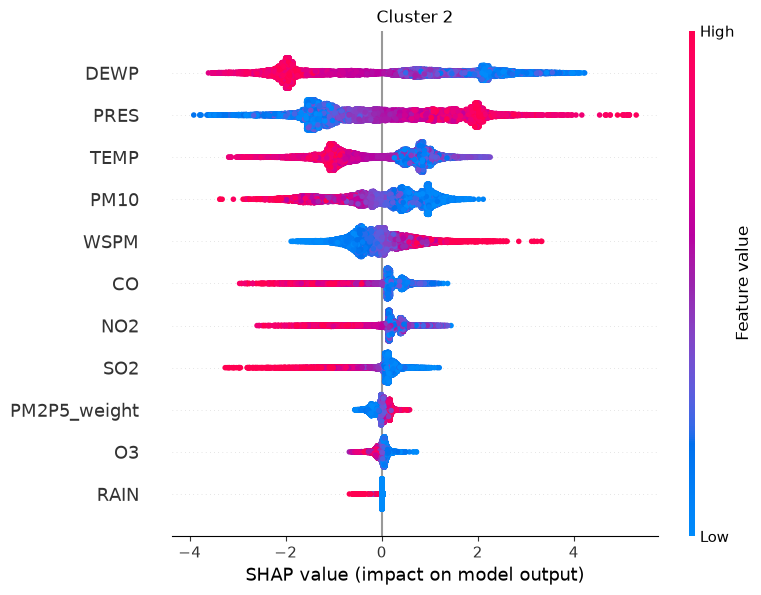

In [56]:
for cnr in range(n_classes):
    shap.summary_plot(class_shap(shap_values_raw, n_test, n_classes, cnr), X, max_display=30, show=False)
    plt.title(f'Cluster {cnr}')
    plt.show()


To explain the clusters, we will plot the three clusters and the boxplot of the features ordered with the feature importance.

# Explain cluster 0

In [57]:
cnr = 0
feature_order = np.argsort(np.sum(np.abs(class_shap(shap_values_raw, n_test, n_classes, cnr)), axis=0))
points, boxplots = plot_cluster(df_km, [X.columns[i] for i in feature_order][::-1][:6], 0)
c0 = alt.hconcat(points, boxplots).properties(title='Cluster 0')
c0

alt.HConcatChart(...)

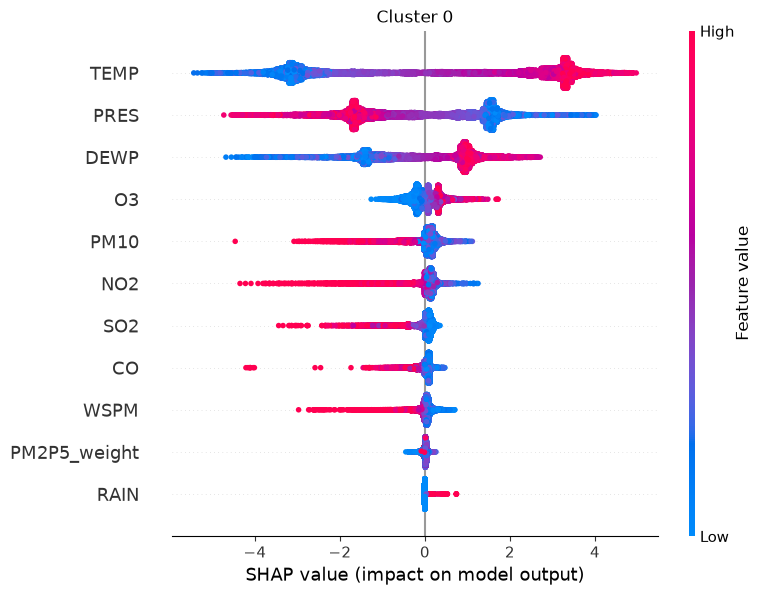

In [58]:
cnr = 0
shap.summary_plot(class_shap(shap_values_raw, n_test, n_classes, cnr), X, max_display=30, show=False)
plt.title(f'Cluster {cnr}')
plt.show()

Cluster 0 can be describe as wines with:
- high density
- high total sulfur dioxide
- high free sulfur dioxide

# Explain cluster 1

In [59]:
X.columns

Index(['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN',
       'WSPM', 'PM2P5_weight'],
      dtype='str')

In [60]:
cnr = 1
feature_order = np.argsort(np.sum(np.abs(class_shap(shap_values_raw, n_test, n_classes, cnr)), axis=0))
points, boxplots = plot_cluster(df_km, [X.columns[i] for i in feature_order][::-1][:6], cnr)
c1 = alt.hconcat(points, boxplots).properties(title=f'Cluster {cnr}')
c1

alt.HConcatChart(...)

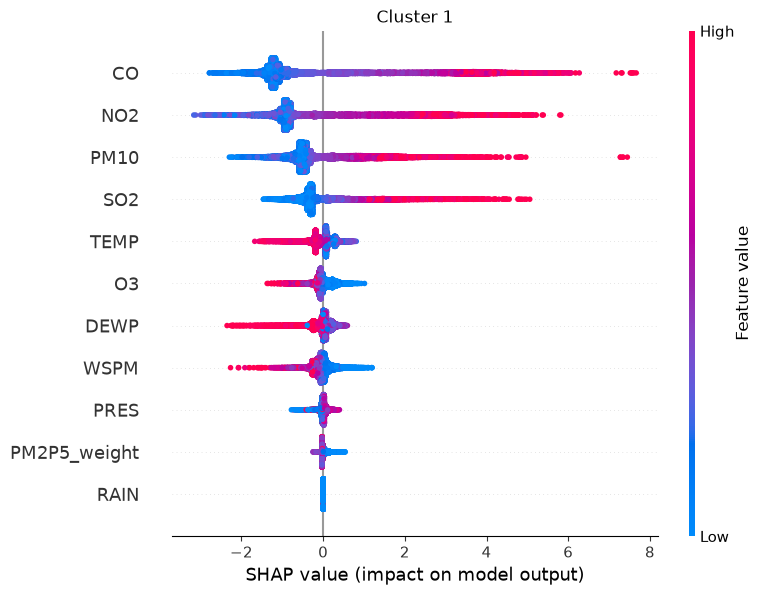

In [61]:
cnr = 1
shap.summary_plot(class_shap(shap_values_raw, n_test, n_classes, cnr), X, max_display=30, show=False)
plt.title(f'Cluster {cnr}')
plt.show()

Cluster 1 contains wines with:
- high pH
- low fixed acidity
- low density (opposite of cluster 0)
- low citric acid
- high on sulphates

# Explain cluster 2

In [62]:
cnr = 2
feature_order = np.argsort(np.sum(np.abs(class_shap(shap_values_raw, n_test, n_classes, cnr)), axis=0))
points, boxplots = plot_cluster(df_km, [X.columns[i] for i in feature_order][::-1][:6], cnr)
c2 = alt.hconcat(points, boxplots).properties(title=f'Cluster {cnr}')
c2

alt.HConcatChart(...)

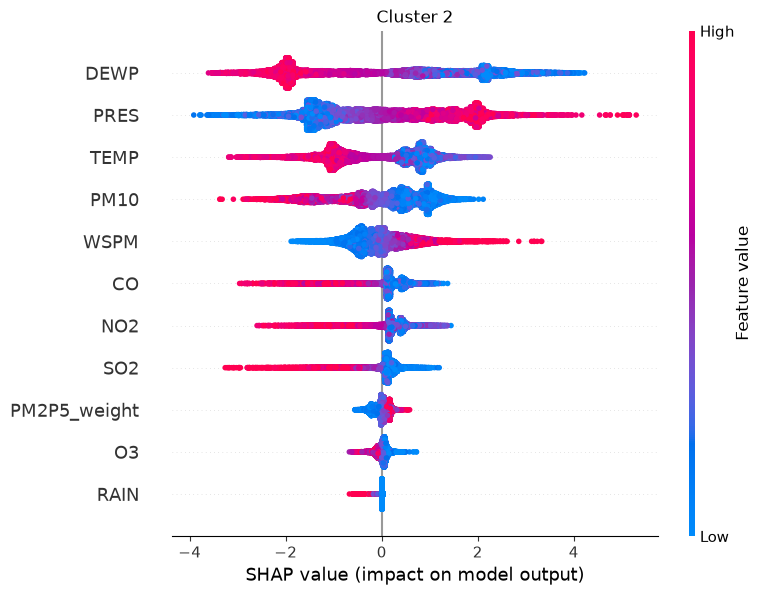

In [63]:
cnr = 2
shap.summary_plot(class_shap(shap_values_raw, n_test, n_classes, cnr), X, max_display=30, show=False)
plt.title(f'Cluster {cnr}')
plt.show()

# How is the quality of the whines in each cluster ?

In [64]:
df_km['PM2.5'] = y
df_km.groupby('cluster')['PM2.5'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,9457.0,80.630475,81.967729,2.0,20.0,55.0,113.0,652.0
1,4220.0,79.415877,79.230892,3.0,20.0,55.5,113.0,712.0
2,6067.0,82.239806,82.819394,3.0,21.0,58.0,113.0,713.0


In [65]:
# Let's plot the distributions of quality score per cluster
alt.Chart(df_km).transform_density(
    density='PM2.5',
    bandwidth=0.3,
    groupby=['cluster'],
    extent= [3, 9],
    counts = True,
    steps=200
).mark_area().encode(
    alt.X('value:Q'),
    alt.Y('density:Q', stack='zero'),
    alt.Color('cluster:N')
).properties(
    title='Distribution of quality of the wines per cluster',
    width=400,
    height=100
)

alt.Chart(...)

We see that the quality has a similar distribution in each cluster.